# Описание проекта 
Сеть фитнес-центров «Культурист-датасаентист» разрабатывает стратегию взаимодействия с клиентами на основе аналитических данных.<br>
Распространённая проблема фитнес-клубов и других сервисов — отток клиентов. Как понять, что клиент больше не с вами? Можно записать в отток тех, кто попросил закрыть договор или удалил аккаунт. Однако клиенты не всегда уходят демонстративно: чаще перестают пользоваться сервисом тихо. <br>
Индикаторы оттока зависят от специфики отрасли. Когда пользователь редко, но стабильно закупается в интернет-магазине — не похоже, что он «отвалился». А вот если две недели не заходит на канал с ежедневно обновляемым контентом, дела плохи: подписчик заскучал и, кажется, оставил вас. <br>
Для фитнес-центра можно считать, что клиент попал в отток, если за последний месяц ни разу не посетил спортзал. Конечно, не исключено, что он уехал на Бали и по приезде обязательно продолжит ходить на фитнес. Однако чаще бывает наоборот. Если клиент начал новую жизнь с понедельника, немного походил в спортзал, а потом пропал — скорее всего, он не вернётся. <br>
Чтобы бороться с оттоком, отдел по работе с клиентами «Культуриста-датасаентиста» перевёл в электронный вид множество клиентских анкет. Ваша задача — провести анализ и подготовить план действий по удержанию клиентов. <br> 
А именно: <br>
научиться прогнозировать вероятность оттока (на уровне следующего месяца) для каждого клиента;<br>
сформировать типичные портреты клиентов: выделить несколько наиболее ярких групп и охарактеризовать их основные свойства;<br>
проанализировать основные признаки, наиболее сильно влияющие на отток;<br>
сформулировать основные выводы и разработать рекомендации по повышению качества работы с клиентами:<br>
1) выделить целевые группы клиентов;<br>
2) предложить меры по снижению оттока;<br>
3) определить другие особенности взаимодействия с клиентами.<br>

# Описание данных 
**Данные клиента за предыдущий до проверки факта оттока месяц:**<br><br>
'gender' — пол;<br>
'Near_Location' — проживание или работа в районе, где находится фитнес-центр;<br>
'Partner' — сотрудник компании-партнёра клуба (сотрудничество с компаниями, чьи сотрудники могут получать скидки на абонемент — в таком случае фитнес-центр хранит информацию о работодателе клиента);<br>
Promo_friends — факт первоначальной записи в рамках акции «приведи друга» (использовал промо-код от знакомого при оплате первого абонемента);<br>
'Phone' — наличие контактного телефона;<br>
'Age' — возраст;<br>
'Lifetime' — время с момента первого обращения в фитнес-центр (в месяцах).<br><br><br>
**Информация на основе журнала посещений, покупок и информация о текущем статусе абонемента клиента:**<br><br>
'Contract_period' — длительность текущего действующего абонемента (месяц, 6 месяцев, год);<br>
'Month_to_end_contract' — срок до окончания текущего действующего абонемента (в месяцах);<br>
'Group_visits' — факт посещения групповых занятий;<br>
'Avg_class_frequency_total' — средняя частота посещений в неделю за все время с начала действия абонемента;<br>
'Avg_class_frequency_current_month' — средняя частота посещений в неделю за предыдущий месяц;<br>
'Avg_additional_charges_total' — суммарная выручка от других услуг фитнес-центра: кафе, спорттовары, косметический и массажный салон.<br>
'Churn' — факт оттока в текущем месяце.

# Загрузка данных

In [4]:
import pandas as pd
import seaborn as sns
import itertools
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [5]:
df = pd.read_csv('')
df.sample(5)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
2453,1,1,1,0,1,12,0,24,225.723233,12.0,2,2.078898,2.091885,0
458,0,0,0,0,1,1,0,27,45.921371,1.0,1,1.301955,0.937431,1
2392,0,1,0,1,1,1,1,31,181.159091,1.0,0,2.079410,1.764481,1
954,0,1,1,1,1,12,1,34,96.087609,11.0,4,2.370811,2.302503,0
1883,0,1,0,0,1,6,0,28,282.564302,6.0,1,0.299677,0.144826,0


# Исследовательский анализ данных (EDA)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

Пропусков в датасете нет.<br> Типы данных все в пордяке, но столбец **'Month_to_end_contract'** можно поменять на int64<br>
Так же имеетются заглавные буквы в названиях столбцов, приведём к единому стилю

In [7]:
df['Month_to_end_contract'] = df['Month_to_end_contract'].astype(int)
df.dtypes

gender                                 int64
Near_Location                          int64
Partner                                int64
Promo_friends                          int64
Phone                                  int64
Contract_period                        int64
Group_visits                           int64
Age                                    int64
Avg_additional_charges_total         float64
Month_to_end_contract                  int64
Lifetime                               int64
Avg_class_frequency_total            float64
Avg_class_frequency_current_month    float64
Churn                                  int64
dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
#Приведём названия столбцов к единому стилю написания
df.columns = df.columns.str.lower()
df.columns

Index(['gender', 'near_location', 'partner', 'promo_friends', 'phone',
       'contract_period', 'group_visits', 'age',
       'avg_additional_charges_total', 'month_to_end_contract', 'lifetime',
       'avg_class_frequency_total', 'avg_class_frequency_current_month',
       'churn'],
      dtype='object')

In [10]:
df.describe()


,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [11]:
df.groupby('churn').describe().T

churn                                              0            1
gender                            count  2939.000000  1061.000000
                                  mean      0.510037     0.510839
                                  std       0.499984     0.500118
                                  min       0.000000     0.000000
                                  25%       0.000000     0.000000
...                                              ...          ...
avg_class_frequency_current_month min       0.000000     0.000000
                                  25%       1.297021     0.421337
                                  50%       2.046697     0.979445
                                  75%       2.740648     1.588576
                                  max       6.146783     3.540271

[104 rows x 2 columns]

Нелогичных данных я не увидел

In [12]:
# Посмотрим те же данные но по группам остался/отток
df.groupby('churn').describe().T

churn                                              0            1
gender                            count  2939.000000  1061.000000
                                  mean      0.510037     0.510839
                                  std       0.499984     0.500118
                                  min       0.000000     0.000000
                                  25%       0.000000     0.000000
...                                              ...          ...
avg_class_frequency_current_month min       0.000000     0.000000
                                  25%       1.297021     0.421337
                                  50%       2.046697     0.979445
                                  75%       2.740648     1.588576
                                  max       6.146783     3.540271

[104 rows x 2 columns]

In [13]:
df.corr()['churn'].abs().sort_values(ascending = False)

churn                                1.000000
lifetime                             0.438220
avg_class_frequency_current_month    0.412348
age                                  0.404735
contract_period                      0.389984
month_to_end_contract                0.381393
avg_class_frequency_total            0.249715
avg_additional_charges_total         0.198697
group_visits                         0.175325
promo_friends                        0.162233
partner                              0.157986
near_location                        0.128098
phone                                0.001177
gender                               0.000708
Name: churn, dtype: float64

По корреляции видим, что когда клиент находится в зале больше раз в неделю или давно ходит в фитнес-зал, то к оттоку он меньше подвержен. Так же имеется некоторая линейная зависимость оттока с возростом  

In [14]:
df['churn'].unique()

array([0, 1])

In [15]:
df.groupby('gender')['group_visits'].count()

gender
0    1959
1    2041
Name: group_visits, dtype: int64

Люди с первоначальной записью в рамках акции «приведи друга» в отток попадает реже

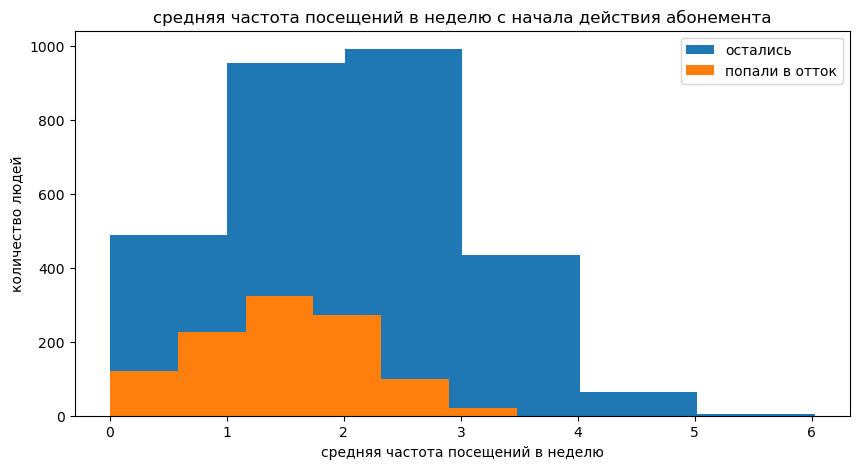

In [16]:
plt.figure(figsize=(10,5))
plt.hist(df[df['churn'] == 0]['avg_class_frequency_total'], bins = 6,  
         label='остались')
plt.hist(df[df['churn'] == 1]['avg_class_frequency_total'], bins = 6, 
         label='попали в отток')  
  
plt.legend(loc='upper right')
plt.title('средняя частота посещений в неделю с начала действия абонемента')
plt.ylabel('количество людей')
plt.xlabel('средняя частота посещений в неделю')
plt.show()

По графику видим, что средняя частота посещений зала влияет на исход останется ли клиент в дальнейшем или нет

In [17]:
small = df[df['avg_class_frequency_total'] <= 2]['avg_class_frequency_total'].count()
big = df[df['avg_class_frequency_total'] > 2]['avg_class_frequency_total'].count()
small_churn = df.query('avg_class_frequency_total <= 2 & churn == 1')['avg_class_frequency_total'].count()
big_churn = df.query('avg_class_frequency_total > 2 & churn == 1')['avg_class_frequency_total'].count()

print('общее количество пользователей у которых ср.количество посещений <=2:', small)
print('общее количество пользователей у которых ср.количество посещений >2:', big)
print('общее количество пользователей у которых ср.количество посещений <=2 и они попали в отток:', small_churn)
print('общее количество пользователей у которых ср.количество посещений >2 и они попали в отток:', big_churn)
print('________________')
#найдем долю попавших в отток
print('доля пользователей которые попали в отток со ср.количеством посещений >2:', round(big_churn / big, 2))
print('доля пользователей которые попали в отток со ср.количеством посещений <=2:', round(small_churn / small, 2))

общее количество пользователей у которых ср.количество посещений <=2: 2245
общее количество пользователей у которых ср.количество посещений >2: 1755
общее количество пользователей у которых ср.количество посещений <=2 и они попали в отток: 812
общее количество пользователей у которых ср.количество посещений >2 и они попали в отток: 249
________________
доля пользователей которые попали в отток со ср.количеством посещений >2: 0.14
доля пользователей которые попали в отток со ср.количеством посещений <=2: 0.36


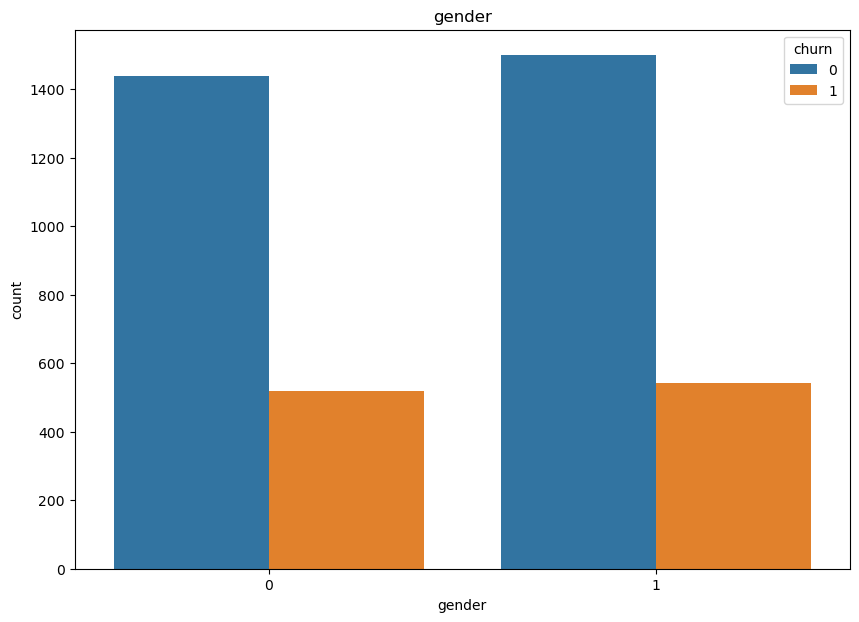

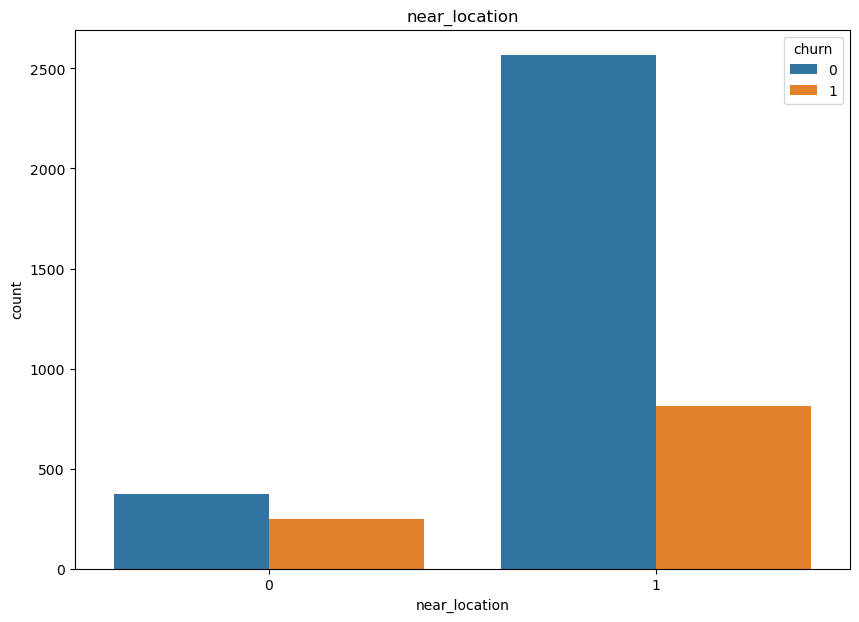

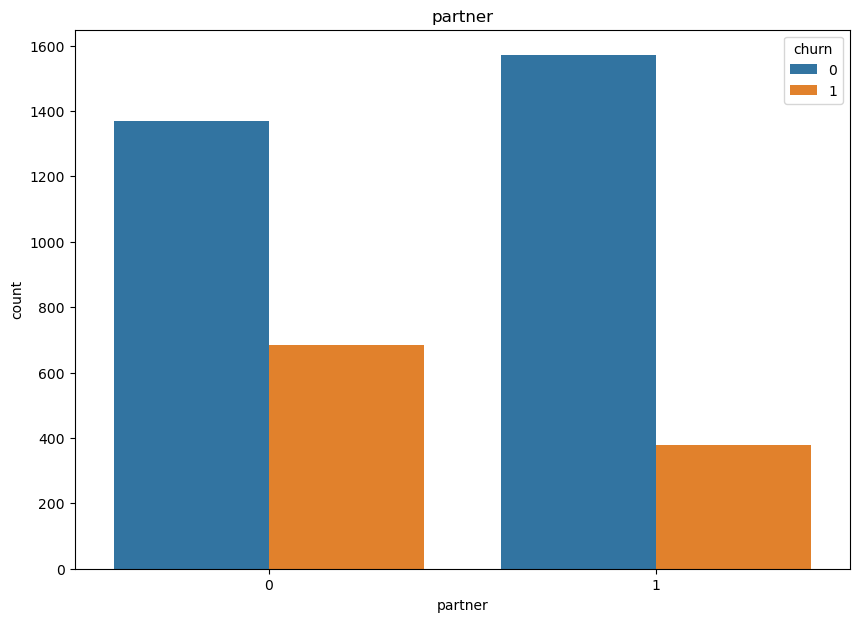

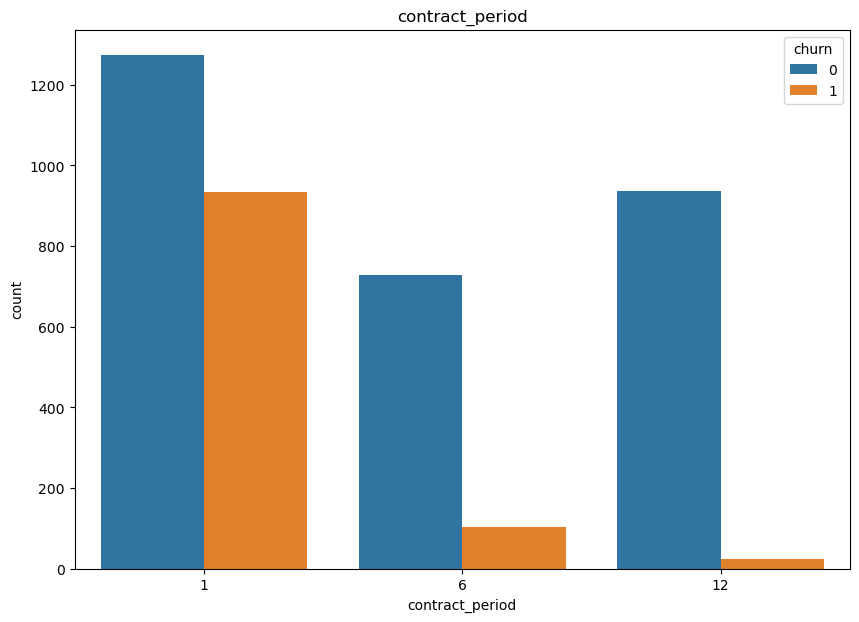

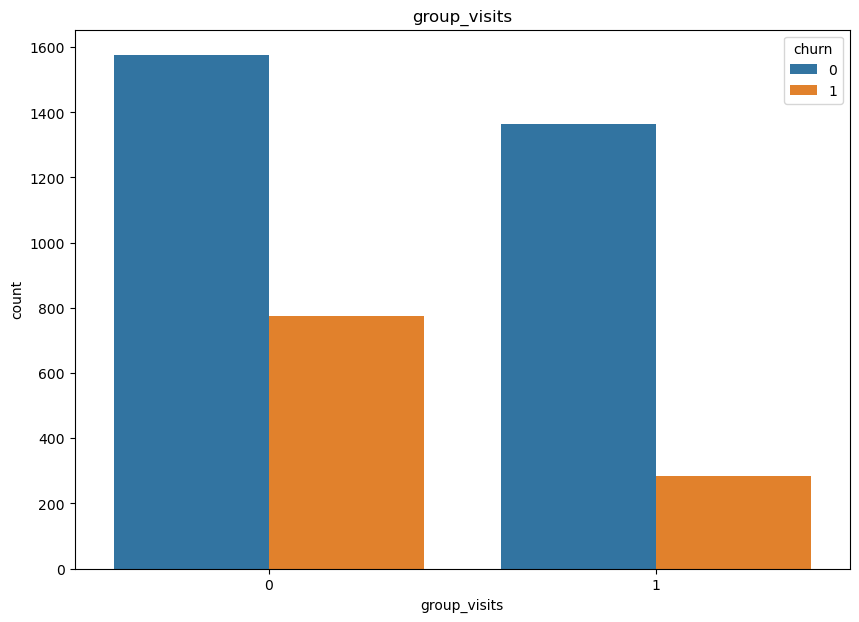

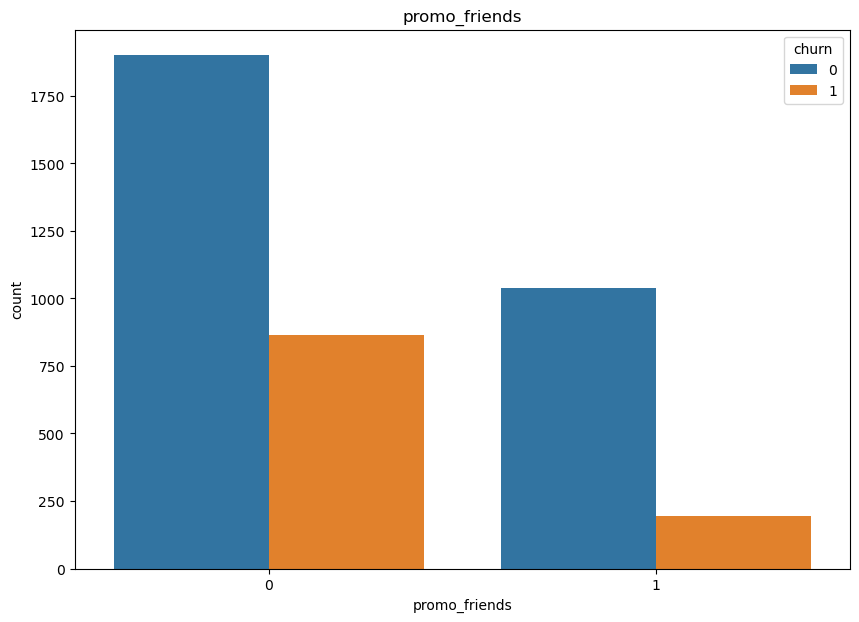

In [18]:
for column in ['gender', 'near_location', 'partner', 'contract_period', 'group_visits', 'promo_friends']:
    plt.figure(figsize=(10, 7))
    sns.countplot(data=df, x = df[column], hue='churn')
    plt.title(column)
    plt.show()

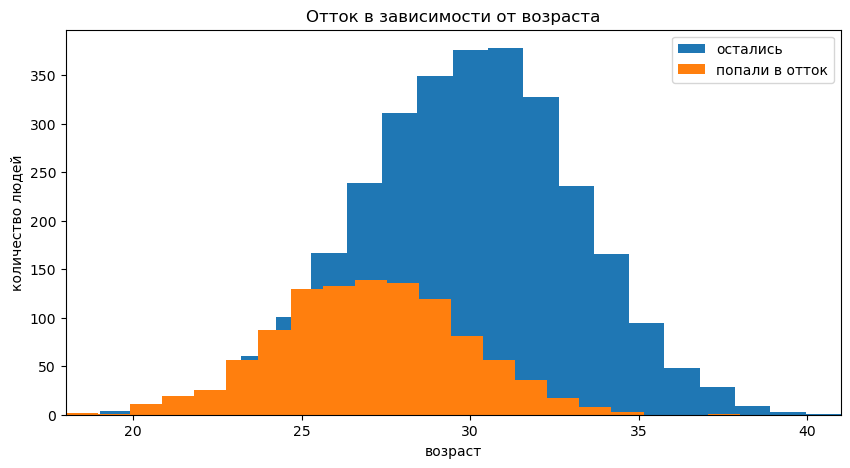

In [19]:
plt.figure(figsize=(10,5))
plt.hist(df[df['churn'] == 0]['age'], bins = 21,  
         label='остались')
plt.hist(df[df['churn'] == 1]['age'], bins = 21, 
         label='попали в отток')
plt.xlim(18,41)
plt.legend(loc='upper right')
plt.title('Отток в зависимости от возраста')
plt.ylabel('количество людей')
plt.xlabel('возраст')
plt.show()

Больше всего оттоку подвержены люди возрастом от 18 до 25 лет. Менее всего люди старше 30

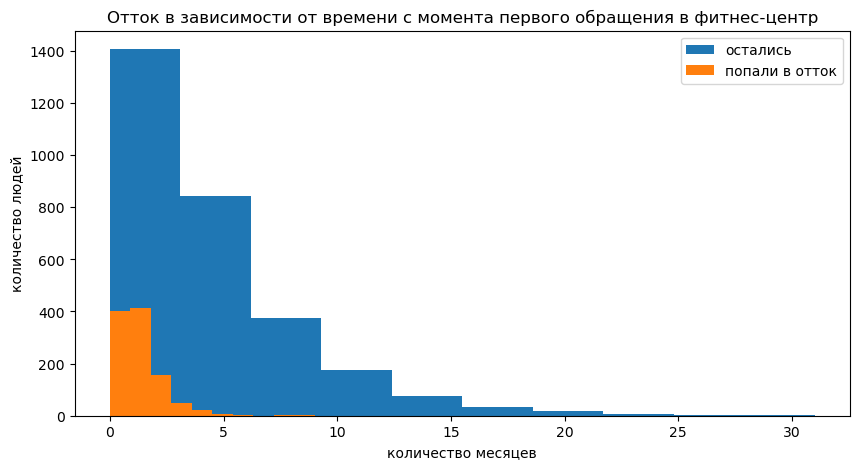

In [20]:
plt.figure(figsize=(10,5))
plt.hist(df[df['churn'] == 0]['lifetime'], bins = 10,  
         label='остались')
plt.hist(df[df['churn'] == 1]['lifetime'], bins = 10, 
         label='попали в отток')

plt.legend(loc='upper right')
plt.title('Отток в зависимости от времени с момента первого обращения в фитнес-центр')
plt.ylabel('количество людей')
plt.xlabel('количество месяцев')
plt.show()

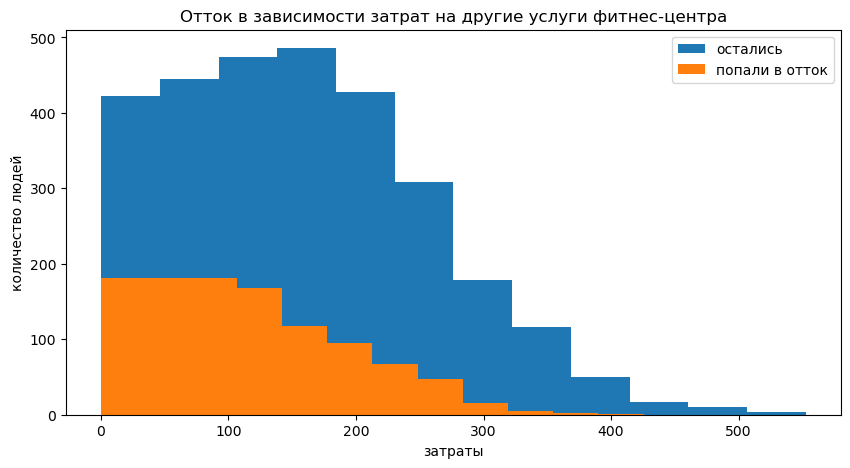

In [21]:
plt.figure(figsize=(10,5))
plt.hist(df[df['churn'] == 0]['avg_additional_charges_total'], bins = 12,  
         label='остались')
plt.hist(df[df['churn'] == 1]['avg_additional_charges_total'], bins = 12, 
         label='попали в отток')
plt.legend(loc='upper right')
plt.title('Отток в зависимости затрат на другие услуги фитнес-центра')
plt.ylabel('количество людей')
plt.xlabel('затраты')
plt.show()

In [22]:
# корреляционная матрица
corr_m = df.corr()
corr_m

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
gender,1.000000,0.006699,-0.010463,-0.005033,-0.008542,0.000502,0.017879,0.013807,-0.009334,-0.001281,0.013579,0.014620,0.009156,0.000708
near_location,0.006699,1.000000,-0.005119,0.210964,-0.015763,0.150233,0.154728,0.058358,0.040761,0.143961,0.070921,0.043127,0.062664,-0.128098
partner,-0.010463,-0.005119,1.000000,0.451960,0.009970,0.306166,0.022710,0.047480,0.022941,0.294632,0.061229,0.024938,0.045561,-0.157986
promo_friends,-0.005033,0.210964,0.451960,1.000000,0.001982,0.244552,0.120170,0.050113,0.036898,0.239553,0.072721,0.028063,0.053768,-0.162233
phone,-0.008542,-0.015763,0.009970,0.001982,1.000000,-0.006893,-0.010099,-0.011403,0.009279,-0.011196,-0.018801,0.008340,0.013375,-0.001177
contract_period,0.000502,0.150233,0.306166,0.244552,-0.006893,1.000000,0.169991,0.138249,0.111445,0.973064,0.170725,0.096211,0.159407,-0.389984
group_visits,0.017879,0.154728,0.022710,0.120170,-0.010099,0.169991,1.000000,0.080934,0.032079,0.163703,0.075853,0.056695,0.075923,-0.175325
age,0.013807,0.058358,0.047480,0.050113,-0.011403,0.138249,0.080934,1.000000,0.080240,0.134511,0.164693,0.119953,0.183095,-0.404735
avg_additional_charges_total,-0.009334,0.040761,0.022941,0.036898,0.009279,0.111445,0.032079,0.080240,1.000000,0.113958,0.079028,0.044426,0.079570,-0.198697
month_to_end_contract,-0.001281,0.143961,0.294632,0.239553,-0.011196,0.973064,0.163703,0.134511,0.113958,1.000000,0.161078,0.085387,0.147605,-0.381393


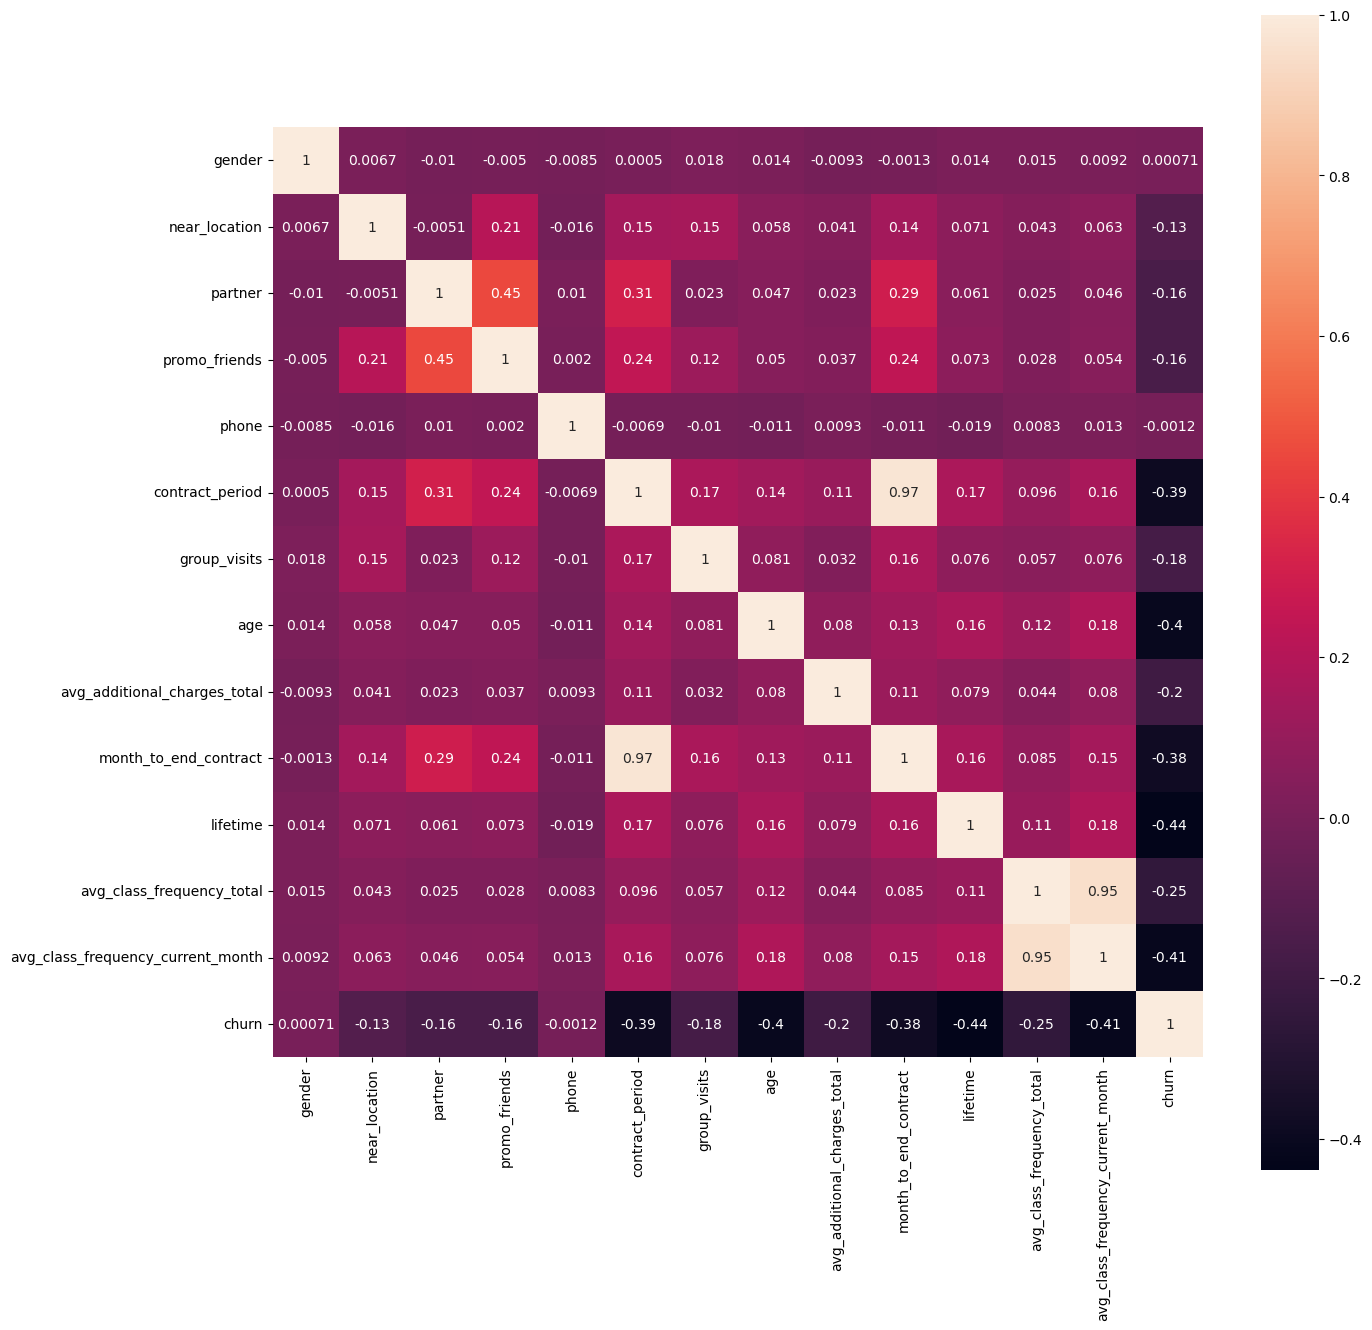

In [23]:
# нарисуем heatmap
plt.figure(figsize = (15,15))
sns.heatmap(corr_m, square = True, annot = True)
plt.show();

# Строю модель прогнозирования оттока клиентов

In [24]:
# разделим данные на признаки (матрица X) и целевую переменную (y)
X = df.drop('churn', axis = 1)
y = df['churn']

In [25]:
# разделим модель на обучающую и валидационную выборку
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify = y)
#посмотрим на размеры выборок
print('количество строк в тренировочной выборке', X_train.shape[0]) 
print('количество столбцов в тренировочной выборке', X_train.shape[1]) 
print('количество строк в тестовой выборке', X_test.shape[0]) 
print('количество столбцов в тестовой выборке', X_test.shape[1]) 

количество строк в тренировочной выборке 3200
количество столбцов в тренировочной выборке 13
количество строк в тестовой выборке 800
количество столбцов в тестовой выборке 13


Обучим модель на train-выборке двумя способами:<br>
логистической регрессией,<br>
случайным лесом.

In [26]:
# задаём алгоритм для нашей модели логистической регрессией
model_log_reg = LogisticRegression(solver='liblinear', random_state=0)
#Для небольших наборов данных "liblinear" является хорошим выбором

In [27]:
# обучаем модель
model_log_reg.fit(X_train, y_train)

LogisticRegression(random_state=0, solver='liblinear')

In [28]:
# делаем прогнозы
predictions = model_log_reg.predict(X_test)

In [29]:
# выведем  метрики для полученного прогноза
print('метрики для логистической регрессии')
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, predictions)))
print('Precision: {:.2f}'.format(precision_score(y_test, predictions)))
print('Recall: {:.2f}'.format(recall_score(y_test, predictions)))

метрики для логистической регрессии
Accuracy: 0.93
Precision: 0.89
Recall: 0.84


In [30]:
model_forest = RandomForestClassifier(n_estimators = 100, random_state=0)

In [31]:
model_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [32]:
predictions_f = model_forest.predict(X_test)
probabilities_f = model_forest.predict_proba(X_test)[:,1]

In [33]:
print('метрики для случайного леса')
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, predictions_f)))
print('Precision: {:.2f}'.format(precision_score(y_test, predictions_f)))
print('Recall: {:.2f}'.format(recall_score(y_test, predictions_f)))

метрики для случайного леса
Accuracy: 0.92
Precision: 0.88
Recall: 0.83


у модели логистической регрессии метрики немного лучше<br>
accuracy - 0.93 против 0.92 у случайного леса<br>
Precision - 0.89 против 0.88<br>
Recall - 0.83 против 0.82

# Делаю кластеризацию клиентов

In [34]:
# стандартизируем данные
sc = StandardScaler()
x_sc = sc.fit_transform(df)

In [35]:
linked = linkage(x_sc, method = 'ward')

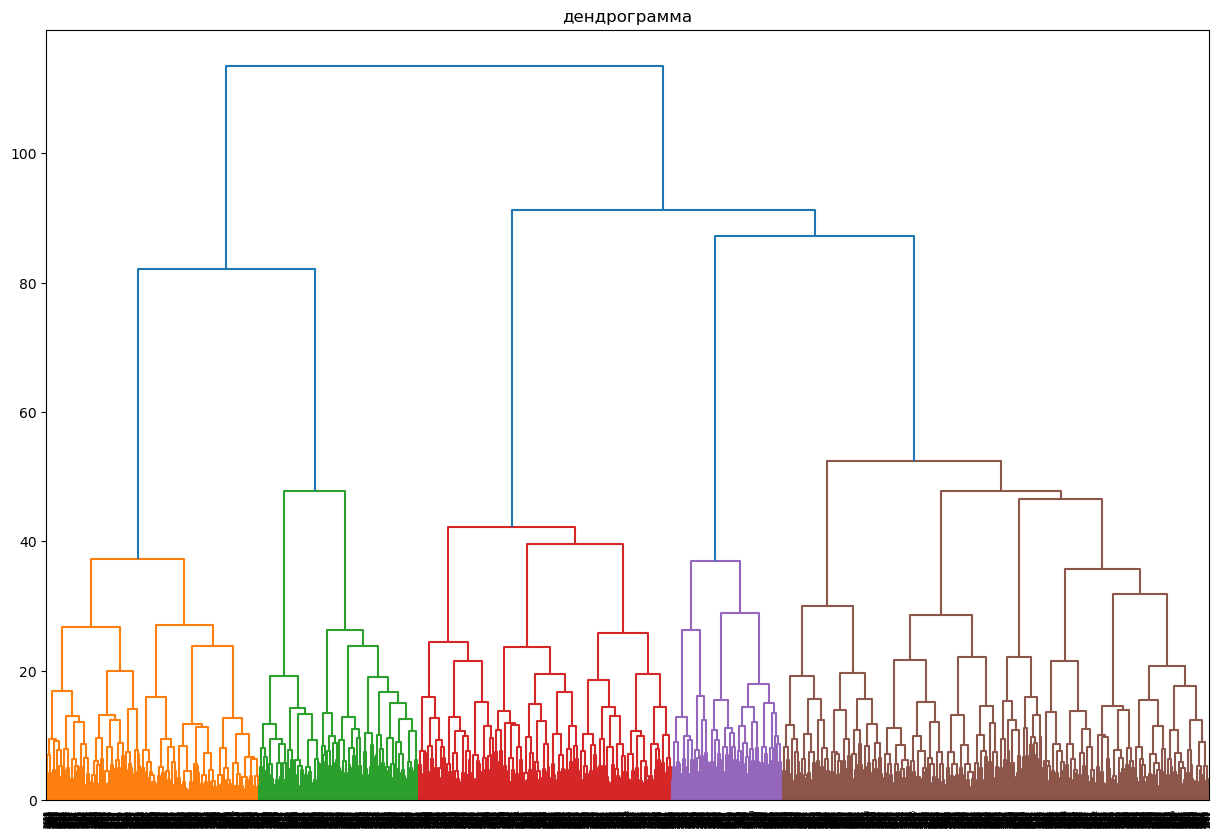

In [36]:
plt.figure(figsize=(15, 10))  
dendrogram(linked, orientation='top')
plt.title('дендрограмма')
plt.show()

Получили распределение 5 кластеров

In [37]:
# задаём модель k_means с числом кластеров 5 и фиксируем значение random_state
km = KMeans(n_clusters=5, random_state=0)
# прогнозируем кластеры для наблюдений (алгоритм присваивает им номера от 0 до 4)
labels = km.fit_predict(x_sc)

In [38]:
# сохраняем метки кластера в поле нашего датасета
df['cluster'] = labels
# выводим статистику по средним значениям наших признаков по кластеру
df.groupby(['cluster']).mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month,churn
cluster,,,,,,,,,,,,,,
0,0.475694,0.825231,0.446759,0.252315,1.000000,2.643519,0.380787,30.021991,153.404553,2.461806,4.671296,1.184034,1.183023,0.001157
1,0.549645,0.842790,0.374704,0.216312,0.998818,2.750591,0.442080,29.977541,160.245842,2.528369,4.593381,2.933126,2.939963,0.007092
2,0.507447,0.760638,0.341489,0.179787,0.997872,1.567021,0.257447,26.908511,115.109065,1.513830,0.976596,1.448700,1.026250,0.997872
3,0.503619,0.938987,0.768356,0.564633,1.000000,11.168563,0.558428,29.895553,161.582993,10.218201,4.703206,2.005548,1.999999,0.015512
4,0.524804,0.866841,0.469974,0.308094,0.000000,4.806789,0.428198,29.331593,144.156967,4.493473,3.945170,1.855107,1.723740,0.263708


In [39]:
df.drop('churn', axis=1).groupby('cluster').mean()

,gender,near_location,partner,promo_friends,phone,contract_period,group_visits,age,avg_additional_charges_total,month_to_end_contract,lifetime,avg_class_frequency_total,avg_class_frequency_current_month
cluster,,,,,,,,,,,,,
0,0.475694,0.825231,0.446759,0.252315,1.000000,2.643519,0.380787,30.021991,153.404553,2.461806,4.671296,1.184034,1.183023
1,0.549645,0.842790,0.374704,0.216312,0.998818,2.750591,0.442080,29.977541,160.245842,2.528369,4.593381,2.933126,2.939963
2,0.507447,0.760638,0.341489,0.179787,0.997872,1.567021,0.257447,26.908511,115.109065,1.513830,0.976596,1.448700,1.026250
3,0.503619,0.938987,0.768356,0.564633,1.000000,11.168563,0.558428,29.895553,161.582993,10.218201,4.703206,2.005548,1.999999
4,0.524804,0.866841,0.469974,0.308094,0.000000,4.806789,0.428198,29.331593,144.156967,4.493473,3.945170,1.855107,1.723740


в 0 кластере нет близости к фитнес-залу, когда в других кластерах почти все клиенты близки, во втором это все<br>
Длительность абонемента в 1 и 4 кластерах близко к максимальному абонементу (12 мес)<br>
Так же среди этих же кластеров соответственная разница в количестве месяцев до окончания абонемента<br> 
Лайфтайм у 2-го кластера самый маленький - 1 мес, можно сказать, что это новички<br>


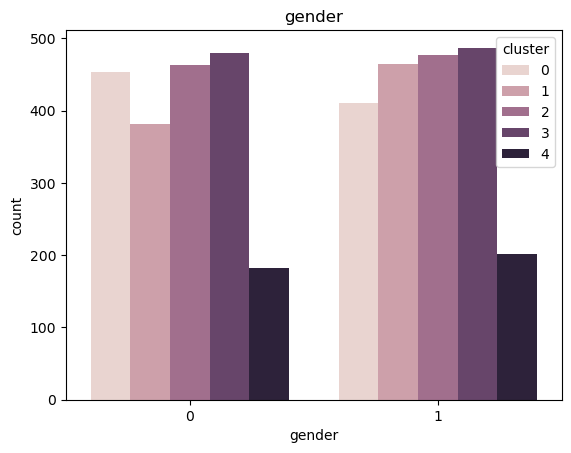

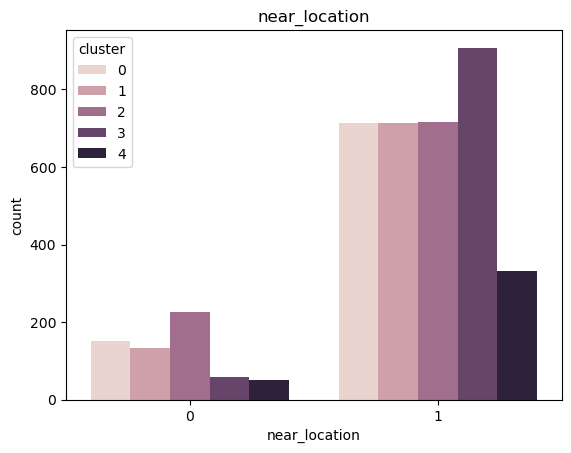

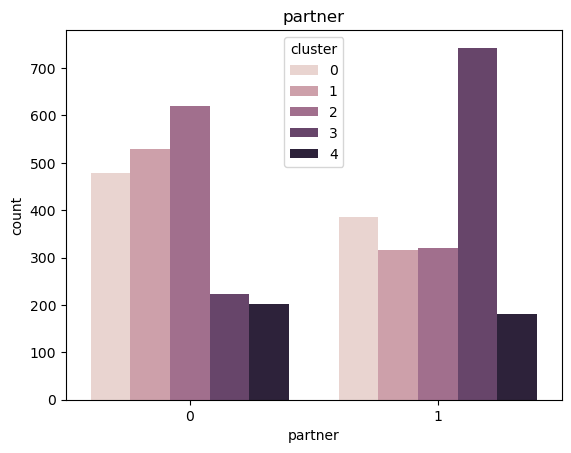

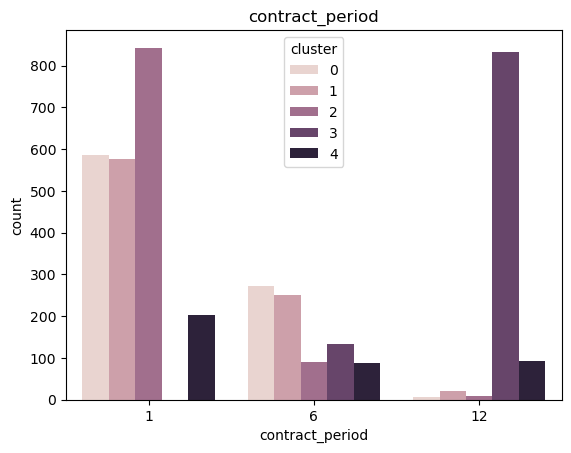

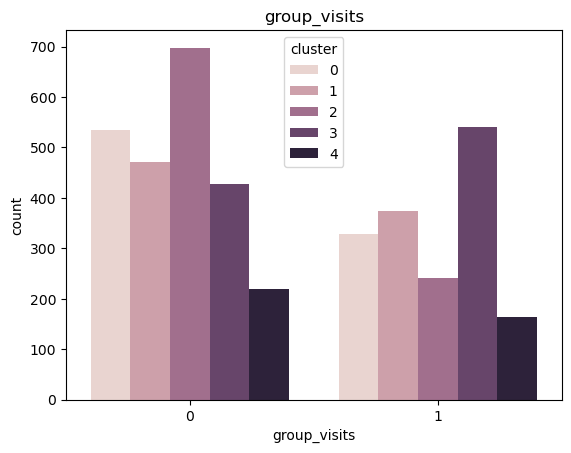

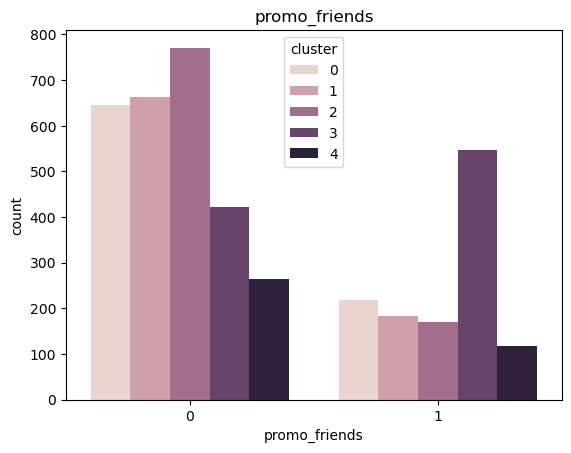

In [40]:
for column in ['gender', 'near_location', 'partner', 'contract_period', 'group_visits', 'promo_friends']:
    sns.countplot(data=df, x = df[column], hue='cluster')
    plt.title(column)
    plt.show()

в гендере нет различий между кластерами<br>
только 0 кластер имеет клиентов у которых у всех фитнес-зал не рядом с домом либо работой<br>
1 и 4 кластеры большинство клиентов являются партнерами с залом(имеют скидки), 2 и 3 кластеры наоборот, 0 поровну<br>
0,2,3 кластеры имеют абонементы 1 месячные, другие кластеры имеют более долгие абонементы<br>
1 и 4 кластеры равноподелены на людей, которые ходят на групповые занятия и которые не ходят. Другие кластеры больше не ходят

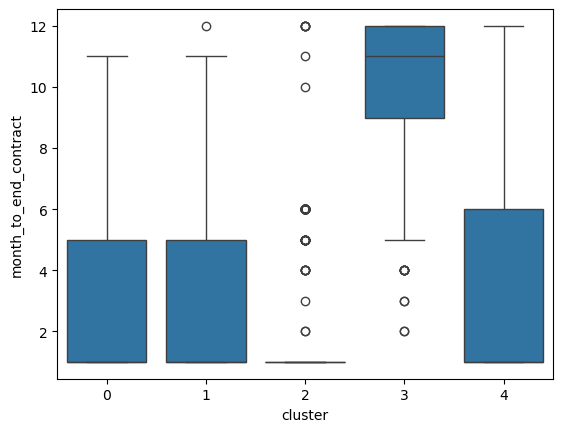

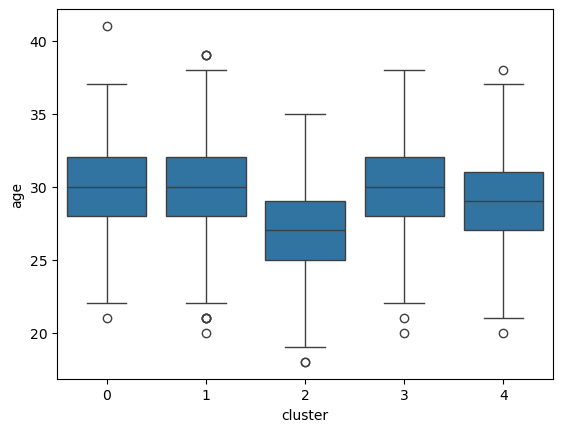

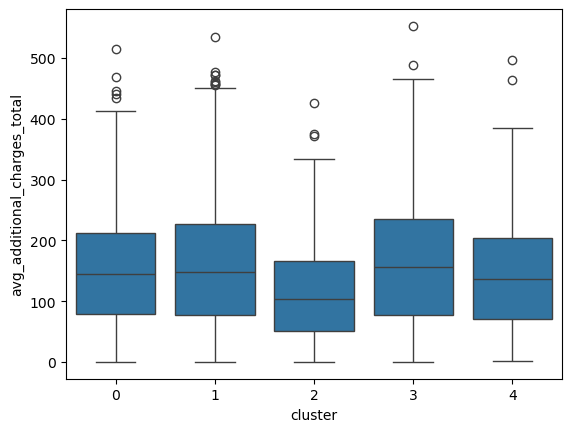

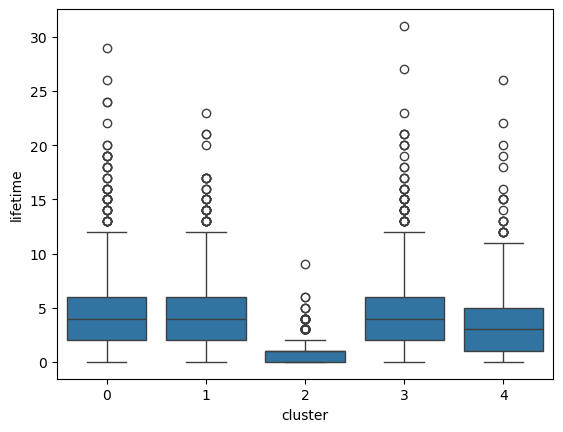

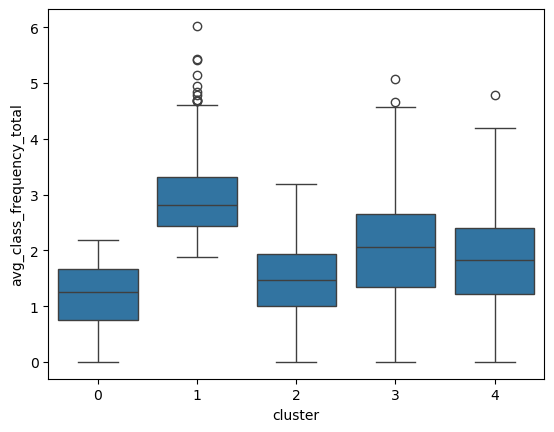

In [41]:
for column in ['month_to_end_contract', 'age', 'avg_additional_charges_total', 'lifetime', 'avg_class_frequency_total']:
    sns.boxplot(data = df, x = 'cluster', y = df[column])
    plt.show()

средний возраст у всех кластеров равен примерно, как и суммы потраченные на другие услуги в ценре<br>
лайфтайм самый большой у 1,3 и 4 кластеров<br>
1 кластер имеет самую большую среднюю посещаемость зала в неделю(почти 3 раза), самую меньшую 4 кластер(1раз)


In [42]:
df.query('churn==1').groupby('cluster')['churn'].count() / df.query('churn==1')['churn'].count()

cluster
0    0.000943
1    0.005655
2    0.884072
3    0.014138
4    0.095193
Name: churn, dtype: float64

# Формулирую выводы и делаю базовые рекомендации по работе с клиентами

Люди которые меньше попадают в отток: У них зал рядом с работой или домом, они часто ходят в зал, покупают абонемент на большие сроки, бОльшая часть имеет скидки т.е партёры.  Груповые занятия сдерживают человека. Люди с первоначальной записью в рамках акции «приведи друга» в отток попадает реже<br>Люди лояльные к фитнесу, также лояльно относимся и к дополнительным услугам, чтобы поддерживать общую тенденцию здорового образа жизни<br>

Чтобы уменьшить отток посетителей, можно давать им скидки на групповые занятия или когда клиент приводит друга.
Нужно развивать дополнительные услуги для спорта (магазин питания, спортивный магазин)